<a href="https://colab.research.google.com/github/yuvraj-013/DA_Projects/blob/Loan_Approval_analysis/loan_approval_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Loan Approval Analysis

**Objective:** Understand what drives `loan_status` (Approved / Rejected) using exploratory data analysis, statistical testing, and predictive modeling, and identify actionable levers that improve approval likelihood.


**Dataset columns:**
`loan_id, no_of_dependents, education, self_employed, income_annum, loan_amount, loan_term, cibil_score, residential_assets_value, commercial_assets_value, luxury_assets_value, bank_asset_value, loan_status`


**Note:** The raw column names in this dataset contain leading spaces (e.g. `' education'`).
Step 1 cleans this immediately so every cell after it can use normal column names.

---


## Step 0 — Setup & Imports

**What this does:** Loads all libraries needed across the notebook — pandas/numpy for data handling, matplotlib/seaborn for visualization, scipy for statistical tests, and scikit-learn for modeling.


In [18]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Optional: install if not available in your Colab runtime
# !pip install xgboost imbalanced-learn -q
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)


## Step 1 — Load Data & Clean Column Names

**What this does:**
- Loads the CSV (upload it to Colab first: click the folder icon → upload, or mount Google Drive).
- Strips whitespace from column names and string values (your headers have leading spaces).
- Standardizes text case for categorical columns.

**Assumption:** The CSV structure matches the columns listed in the project brief, with `loan_status` as a clean binary Approved/Rejected outcome and no partial/pending states.


In [68]:
# Option B: Uploaded Directly from Colab
df= pd.read_csv('/content/new_loan_approval_dataset.csv')

# Clean column names: strip whitespace
df.columns = df.columns.str.strip()

print("Cleaned columns:")
df.columns.tolist()

# Clean string/object column values (strip whitespace, standardize case)
obj_cols = df.select_dtypes(include="object").columns
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip()

df['loan_term'] = pd.to_numeric(df['loan_term'], errors='coerce').astype('Int64')


Cleaned columns:


In [69]:
df.head(6)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected


In [70]:
# Basic structural check
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate loan_id count:", df["loan_id"].duplicated().sum())

Shape: (4269, 13)

Data types:
 loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    Int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

Missing values:
 loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Duplicate loan_id count: 0


# Step 2 — Feature Engineering
**Aim:** Create derived financial ratios that are usually more predictive of loan approval than raw values alone — because approval decisions are relative (e.g. debt relative to income), not absolute.


<div style="font-size: 25px; font-family: Arial, sans-serif; max-width: 100%; overflow-x: auto;">

| Feature | Formula | Why it matters |
| :--- | :--- | :--- |
| `total_assets` | `sum of all 4 asset columns` | Overall collateral strength |
| `debt_to_income` | `loan_amount / income_annum` | How much is being borrowed relative to earnings |
| `loan_to_asset_ratio` | `loan_amount / total_assets` | Risk exposure relative to collateral |
| `asset_to_income` | `total_assets / income_annum` | Wealth cushion relative to income |

</div>


In [73]:
df["total_assets"] = (
    df["residential_assets_value"]
    + df["commercial_assets_value"]
    + df["luxury_assets_value"]
    + df["bank_asset_value"]
)

# Avoid divide-by-zero issues: Replace zero income or asset values with NaN for ratio calculations

df["debt_to_income"] = df["loan_amount"] / df["income_annum"].replace(0, np.nan)
df["loan_to_asset_ratio"] = df["loan_amount"] / df["total_assets"].replace(0, np.nan)
df["asset_to_income"] = df["total_assets"] / df["income_annum"].replace(0, np.nan)

df[["total_assets", "debt_to_income", "loan_to_asset_ratio", "asset_to_income"]].describe()

,total_assets,debt_to_income,loan_to_asset_ratio,asset_to_income
count,4.269000e+03,4269.000000,4269.000000,4269.000000
mean,3.254877e+07,2.984807,0.486857,6.390858
std,1.950656e+07,0.595496,0.145554,1.251145
min,4.000000e+05,1.500000,0.176471,2.000000
25%,1.630000e+07,2.464286,0.382231,5.500000
50%,3.150000e+07,3.000000,0.466667,6.413043
75%,4.720000e+07,3.500000,0.565820,7.267857
max,9.070000e+07,4.000000,1.333333,10.142857


## Step 3 — Encode Categorical Variables

**Aim:** Convert text categories into numeric form for statistical tests and modeling, while keeping the original columns for readable plots.




In [74]:
print("education categories:", df["education"].unique())
print("self_employed categories:", df["self_employed"].unique())
print("loan_status categories:", df["loan_status"].unique())

education categories: ['Graduate' 'Not Graduate']
self_employed categories: ['No' 'Yes']
loan_status categories: ['Approved' 'Rejected']


In [75]:
# Kept original Columns for plotting, added encoded versions for stats/modeling

# Converted the values to lower-case and mapped using Lambda function
df["education_enc"] = np.where(df['education'].str.lower()=='graduate',1,0)
df["self_employed_enc"] = df["self_employed"].map(lambda x: 1 if x.lower() == "yes" else 0)
df["loan_status_enc"] = df["loan_status"].map(lambda x: 1 if x.lower() == "approved" else 0)

# Sanity check: confirm no NaNs introduced by mapping (would mean unexpected category labels)
print(df[["education_enc", "self_employed_enc", "loan_status_enc"]].isnull().sum())

education_enc        0
self_employed_enc    0
loan_status_enc      0
dtype: int64


## Step 4 — Exploratory Data Analysis: Univariate

**Aim:** Look at each variable in isolation before comparing against `loan_status`, to understand scale, spread, and class balance.

**Why check class balance first:** If approvals/rejections are heavily skewed (e.g. 80/20), accuracy alone will be a misleading metric later, and we'll need to handle imbalance (Step 9).


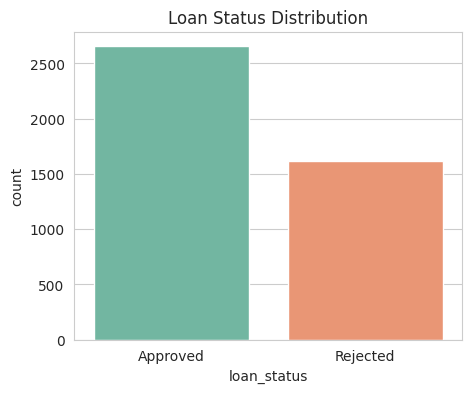

loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64


In [41]:
# Class balance of the target variable
plt.figure(figsize=(5,4))
sns.countplot(x="loan_status", data=df, hue="loan_status",palette="Set2")
plt.title("Loan Status Distribution")
plt.show()

print(df["loan_status"].value_counts(normalize=True) * 100)


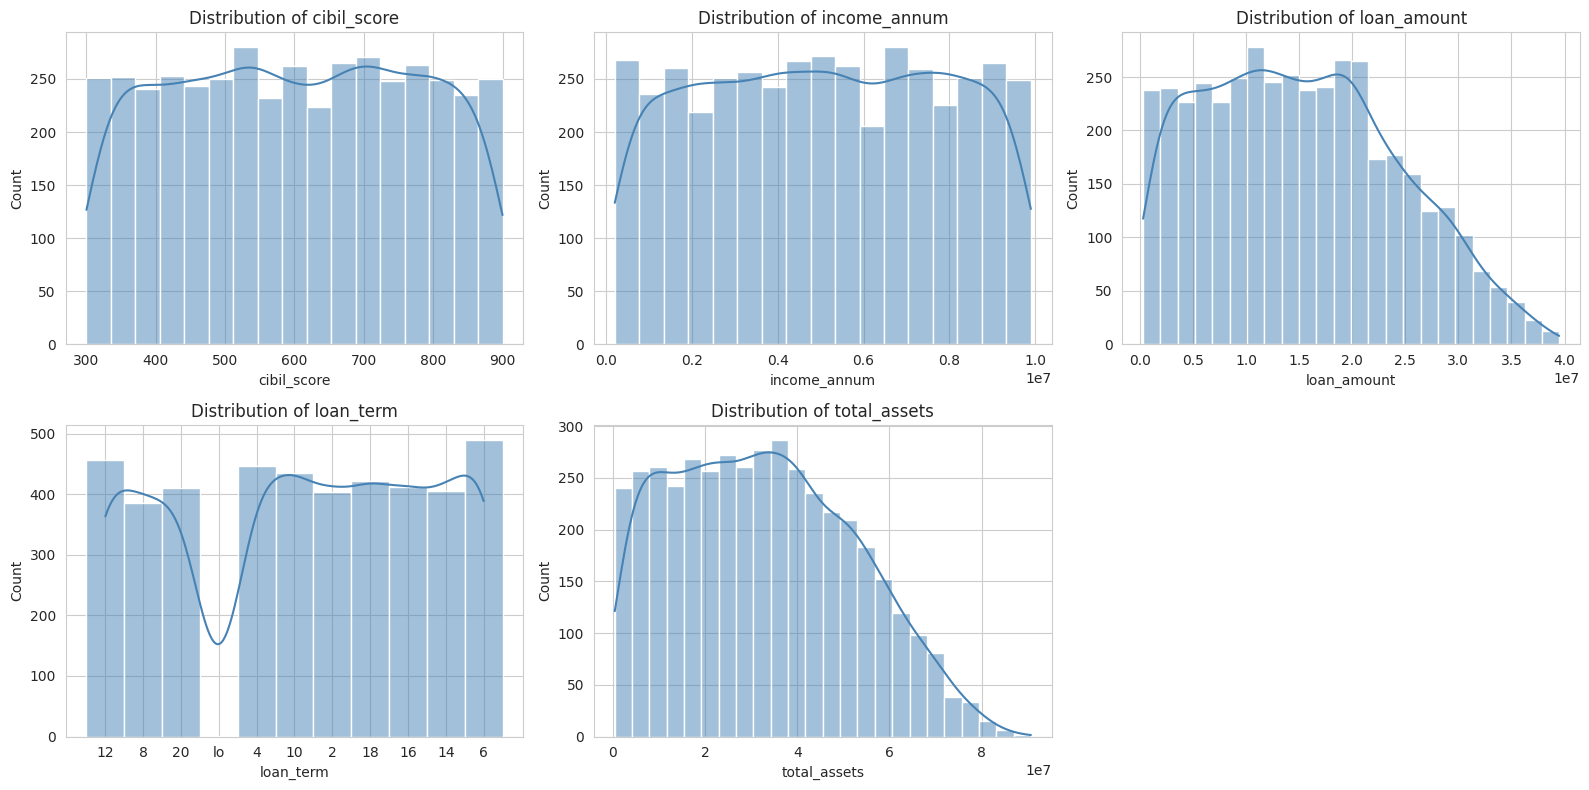

In [39]:
# Distributions of key numeric features
num_cols = ["cibil_score", "income_annum", "loan_amount", "loan_term", "total_assets"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


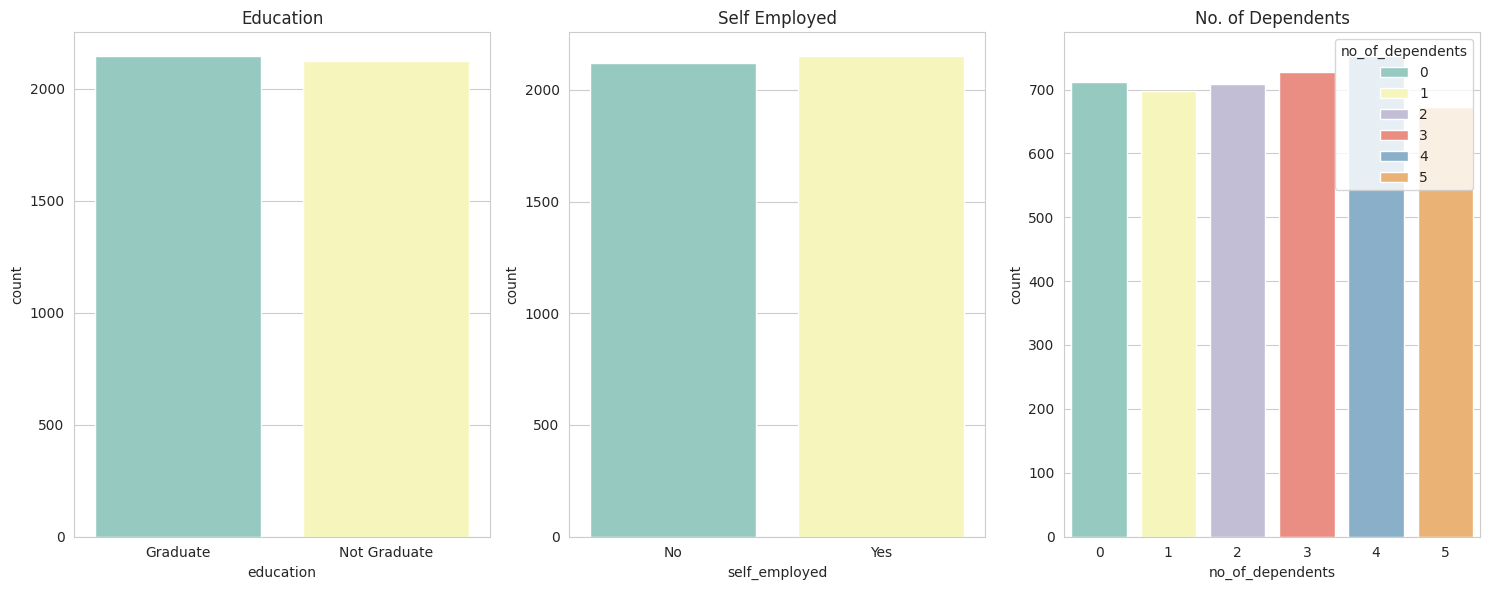

In [44]:
# Categorical counts
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
sns.countplot(x="education", data=df, ax=axes[0], hue = "education",palette="Set3")
sns.countplot(x="self_employed", data=df, ax=axes[1], hue= "self_employed", palette="Set3")
sns.countplot(x="no_of_dependents", data=df, ax=axes[2], hue="no_of_dependents", palette="Set3")
axes[0].set_title("Education")
axes[1].set_title("Self Employed")
axes[2].set_title("No. of Dependents")
plt.tight_layout()
plt.show()


## Step 5 — Exploratory Data Analysis: Bivariate (vs `loan_status`)

**Aim:** This is the core analysis — every plot here directly compares a feature against loan outcome, to visually surface which variables separate Approved from Rejected applicants.


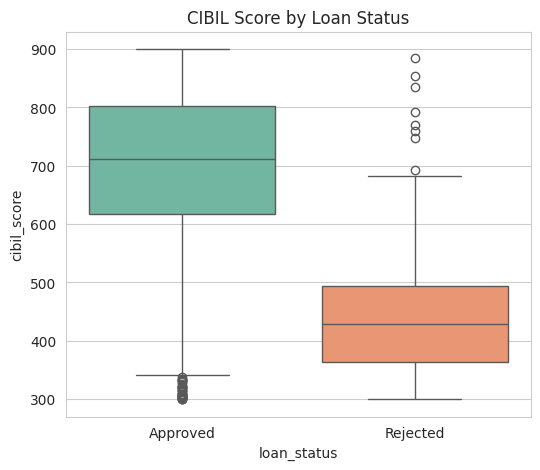

In [45]:
# CIBIL score vs loan status — typically the strongest signal in these datasets
plt.figure(figsize=(6,5))
sns.boxplot(x="loan_status", y="cibil_score", data=df, hue="loan_status",palette="Set2")
plt.title("CIBIL Score by Loan Status")
plt.show()


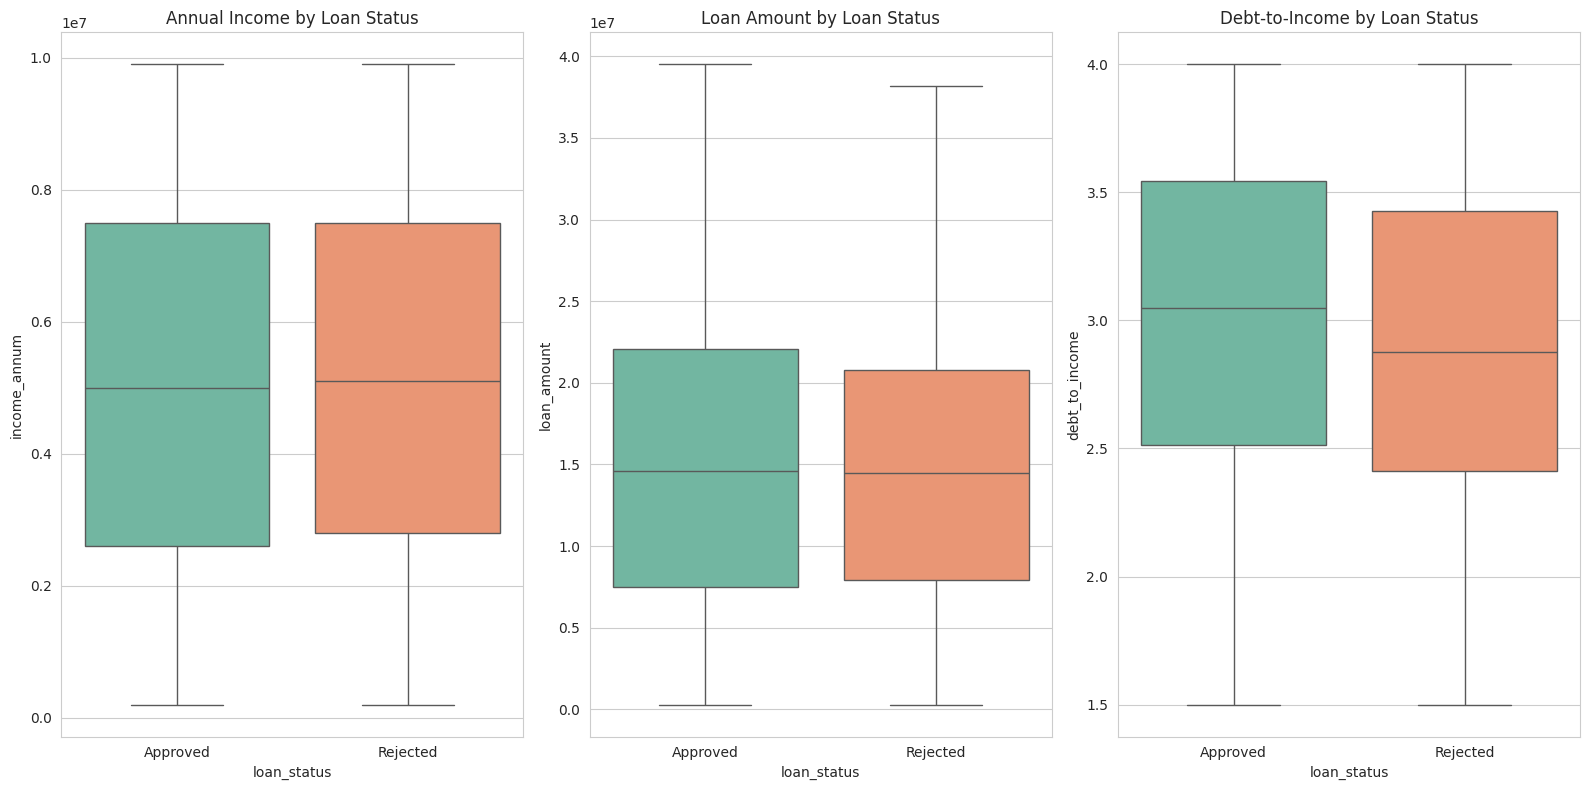

In [48]:
# Income, loan amount, and debt-to-income vs loan status
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
sns.boxplot(x="loan_status", y="income_annum", data=df, ax=axes[0], hue = "loan_status",palette="Set2")
sns.boxplot(x="loan_status", y="loan_amount", data=df, ax=axes[1], hue = "loan_status",palette="Set2")
sns.boxplot(x="loan_status", y="debt_to_income", data=df, ax=axes[2], hue = "loan_status",palette="Set2")
axes[0].set_title("Annual Income by Loan Status")
axes[1].set_title("Loan Amount by Loan Status")
axes[2].set_title("Debt-to-Income by Loan Status")
plt.tight_layout()
plt.show()


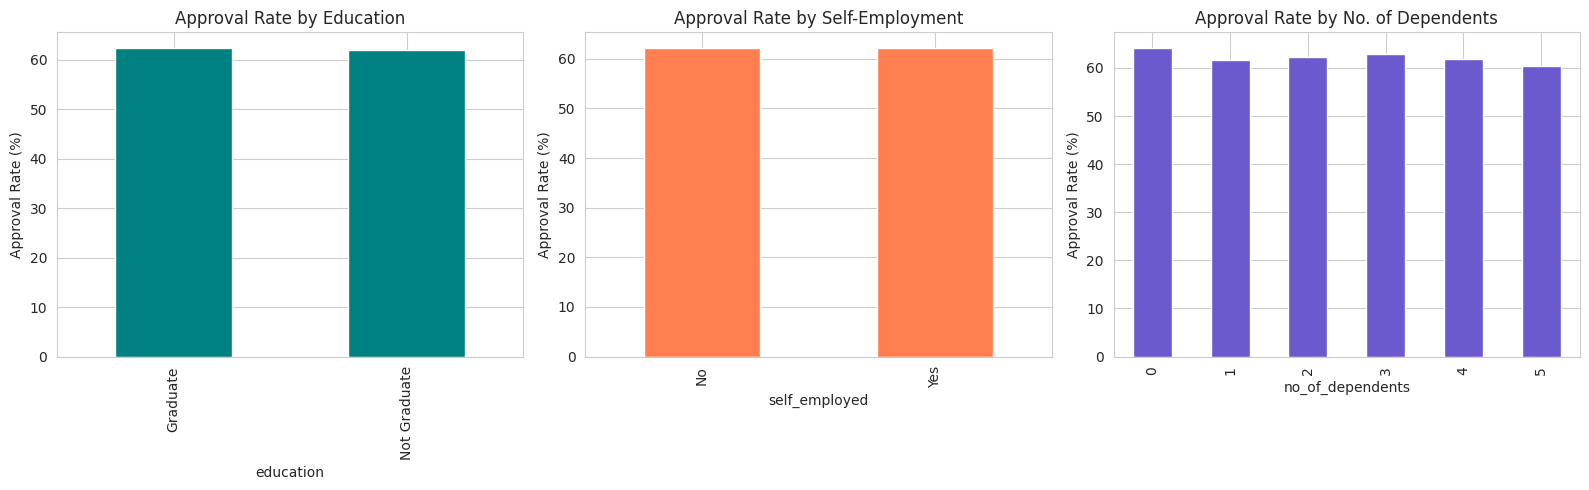

In [49]:
# Approval rate (%) by categorical variables
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

approval_by_edu = df.groupby("education")["loan_status_enc"].mean() * 100
approval_by_edu.plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Approval Rate by Education")
axes[0].set_ylabel("Approval Rate (%)")

approval_by_emp = df.groupby("self_employed")["loan_status_enc"].mean() * 100
approval_by_emp.plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Approval Rate by Self-Employment")
axes[1].set_ylabel("Approval Rate (%)")

approval_by_dep = df.groupby("no_of_dependents")["loan_status_enc"].mean() * 100
approval_by_dep.plot(kind="bar", ax=axes[2], color="slateblue")
axes[2].set_title("Approval Rate by No. of Dependents")
axes[2].set_ylabel("Approval Rate (%)")

plt.tight_layout()
plt.show()


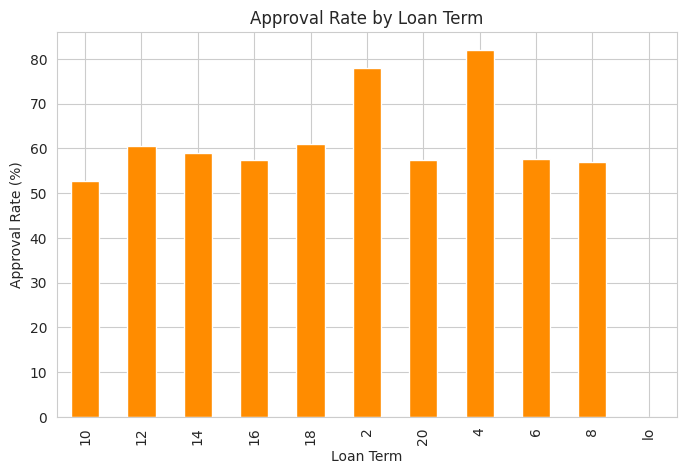

In [50]:
# Approval rate by loan term
plt.figure(figsize=(8,5))
term_approval = df.groupby("loan_term")["loan_status_enc"].mean() * 100
term_approval.plot(kind="bar", color="darkorange")
plt.title("Approval Rate by Loan Term")
plt.ylabel("Approval Rate (%)")
plt.xlabel("Loan Term")
plt.show()


/tmp/ipykernel_4628/4075233429.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  asset_approval = df.groupby("assets_quartile")["loan_status_enc"].mean() * 100


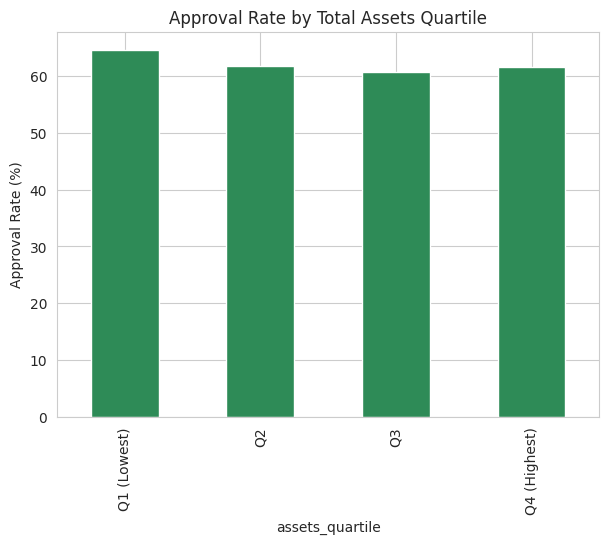

In [51]:
# Approval rate by total_assets quartile
df["assets_quartile"] = pd.qcut(df["total_assets"], 4, labels=["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"])
plt.figure(figsize=(7,5))
asset_approval = df.groupby("assets_quartile")["loan_status_enc"].mean() * 100
asset_approval.plot(kind="bar", color="seagreen")
plt.title("Approval Rate by Total Assets Quartile")
plt.ylabel("Approval Rate (%)")
plt.show()


/tmp/ipykernel_4628/1574207670.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cibil_band_approval = df.groupby("cibil_band")["loan_status_enc"].mean() * 100


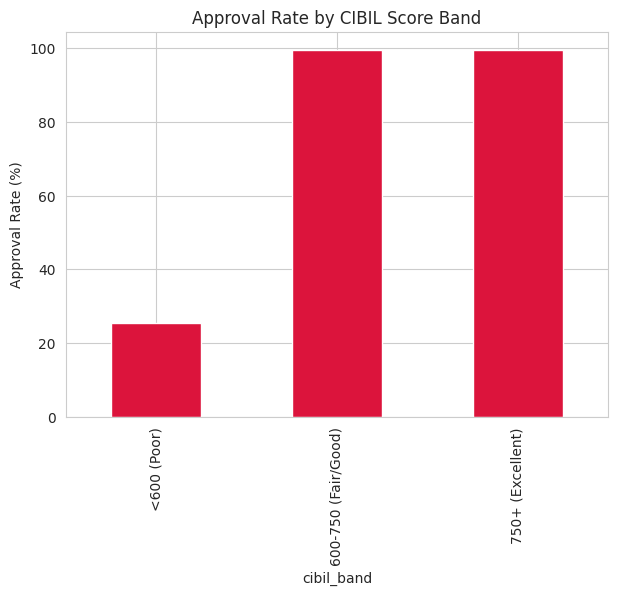

cibil_band
<600 (Poor)            25.279851
600-750 (Fair/Good)    99.533582
750+ (Excellent)       99.430199
Name: loan_status_enc, dtype: float64


In [52]:
# CIBIL score bands — a common real-world cutoff analysis
bins = [0, 600, 750, 900]
labels = ["<600 (Poor)", "600-750 (Fair/Good)", "750+ (Excellent)"]
df["cibil_band"] = pd.cut(df["cibil_score"], bins=bins, labels=labels)

plt.figure(figsize=(7,5))
cibil_band_approval = df.groupby("cibil_band")["loan_status_enc"].mean() * 100
cibil_band_approval.plot(kind="bar", color="crimson")
plt.title("Approval Rate by CIBIL Score Band")
plt.ylabel("Approval Rate (%)")
plt.show()

print(cibil_band_approval)


## Step 6 — Correlation Analysis

**Aim:** Quantifies linear relationships between all numeric features (including the encoded target) in one view, to spot which variables move together with `loan_status_enc`.

**Caveat:** Correlation only captures linear relationships — a low correlation doesn't rule out a variable being important in a non-linear sense (tree-based models in Step 8 will catch that).


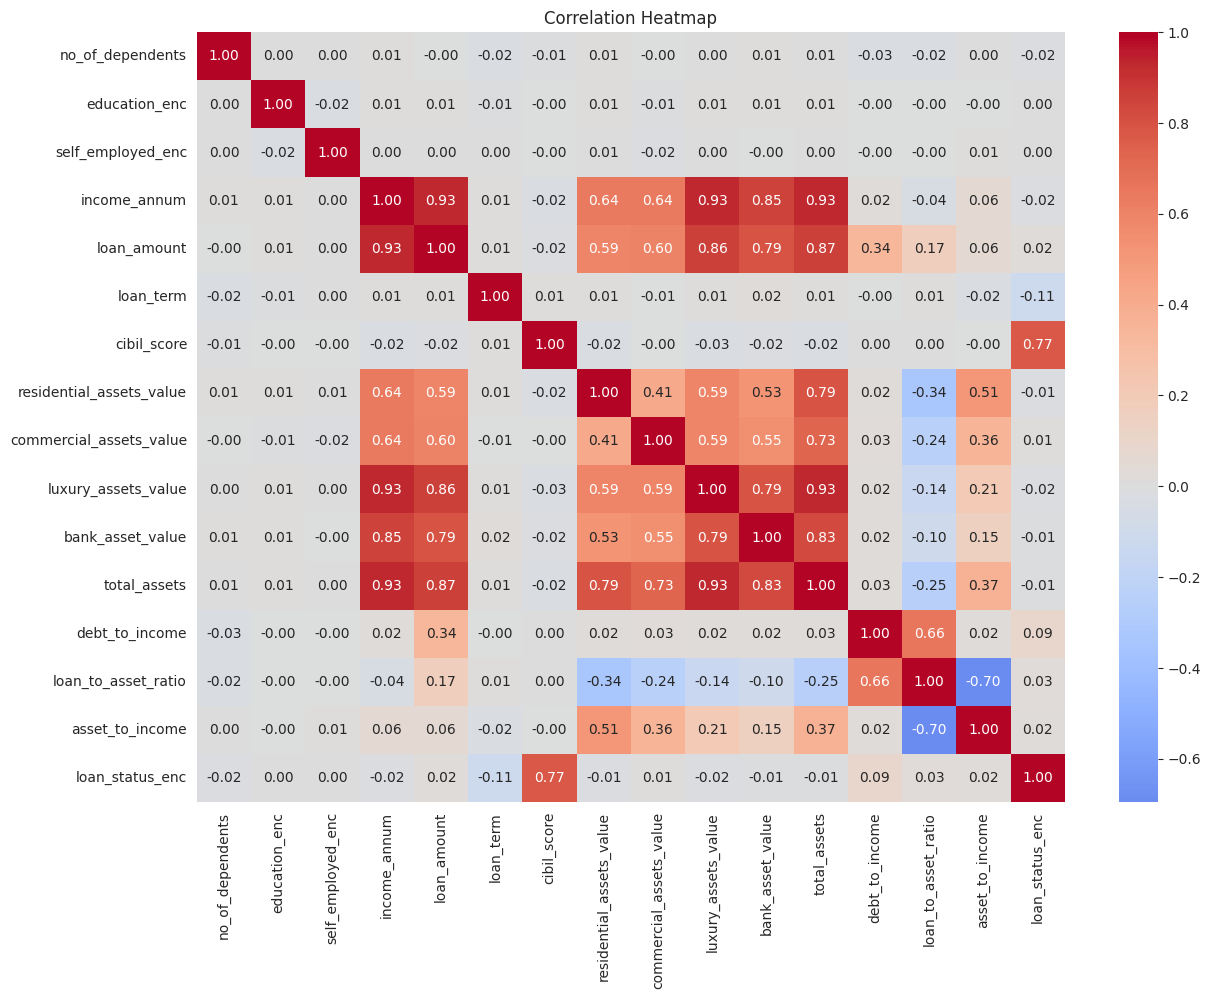

loan_status_enc             1.000000
cibil_score                 0.770518
debt_to_income              0.087726
loan_to_asset_ratio         0.029763
asset_to_income             0.024357
loan_amount                 0.016150
commercial_assets_value     0.008246
education_enc               0.004918
self_employed_enc           0.000345
bank_asset_value           -0.006778
total_assets               -0.011281
residential_assets_value   -0.014367
income_annum               -0.015189
luxury_assets_value        -0.015465
no_of_dependents           -0.018114
loan_term                  -0.113036
Name: loan_status_enc, dtype: float64


In [76]:
numeric_for_corr = [
    "no_of_dependents", "education_enc", "self_employed_enc",
    "income_annum", "loan_amount", "loan_term", "cibil_score",
    "residential_assets_value", "commercial_assets_value",
    "luxury_assets_value", "bank_asset_value", "total_assets",
    "debt_to_income", "loan_to_asset_ratio", "asset_to_income",
    "loan_status_enc"
]

corr_matrix = df[numeric_for_corr].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Correlation with the target specifically, sorted
print(corr_matrix["loan_status_enc"].sort_values(ascending=False))


## Step 7 — Statistical Significance Testing

**What this does:** Moves beyond visual patterns to formally test whether differences are statistically significant, not just noise.

- **Chi-square test** — for categorical variables (`education`, `self_employed`) vs `loan_status`. Tests whether the categories are independent of the outcome.
- **T-test** — for continuous variables (`cibil_score`, `income_annum`) vs `loan_status`. Tests whether the mean differs significantly between Approved and Rejected groups.

**Interpretation rule used throughout:** p-value < 0.05 → statistically significant relationship with `loan_status`.


In [77]:
# Chi-square tests for categorical variables
for col in ["education", "self_employed"]:
    contingency = pd.crosstab(df[col], df["loan_status"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col}: chi2={chi2:.3f}, p-value={p:.4f} -> "
          f"{'Significant' if p < 0.05 else 'Not significant'}")


education: chi2=0.084, p-value=0.7720 -> Not significant
self_employed: chi2=0.000, p-value=1.0000 -> Not significant


In [78]:
# T-tests for continuous variables
approved = df[df["loan_status_enc"] == 1]
rejected = df[df["loan_status_enc"] == 0]

for col in ["cibil_score", "income_annum", "loan_amount", "debt_to_income", "total_assets"]:
    t_stat, p_val = ttest_ind(approved[col].dropna(), rejected[col].dropna(), equal_var=False)
    print(f"{col}: t-stat={t_stat:.3f}, p-value={p_val:.4f} -> "
          f"{'Significant' if p_val < 0.05 else 'Not significant'}")


cibil_score: t-stat=87.896, p-value=0.0000 -> Significant
income_annum: t-stat=-0.997, p-value=0.3188 -> Not significant
loan_amount: t-stat=1.069, p-value=0.2852 -> Not significant
debt_to_income: t-stat=5.747, p-value=0.0000 -> Significant
total_assets: t-stat=-0.740, p-value=0.4593 -> Not significant


## Step 8 — Predictive Modeling

**Aim:** Builds classifiers to predict `loan_status` and, more importantly, extracts **feature importance** — a direct, ranked answer to "what drives loan approval."

**Models used:**
 **XGBoost** — gradient boosting, typically the top performer on tabular data like this.

**Assumption:** We're not doing time-based validation since there's no temporal column — a standard random train/test split is used.


In [79]:
feature_cols = [
    "no_of_dependents", "education_enc", "self_employed_enc",
    "income_annum", "loan_amount", "loan_term", "cibil_score",
    "residential_assets_value", "commercial_assets_value",
    "luxury_assets_value", "bank_asset_value",
    "total_assets", "debt_to_income", "loan_to_asset_ratio", "asset_to_income"
]

X = df[feature_cols]
y = df["loan_status_enc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True))


Train shape: (3415, 15)  Test shape: (854, 15)
Train target balance:
 loan_status_enc
1    0.622255
0    0.377745
Name: proportion, dtype: float64


In [81]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

    print(f"\n--- {name} ---")
    print("Accuracy :", round(accuracy_score(y_te, y_pred), 4))
    print("Precision:", round(precision_score(y_te, y_pred), 4))
    print("Recall   :", round(recall_score(y_te, y_pred), 4))
    print("F1 Score :", round(f1_score(y_te, y_pred), 4))
    if y_proba is not None:
        print("ROC-AUC  :", round(roc_auc_score(y_te, y_proba), 4))

    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Rejected","Approved"], yticklabels=["Rejected","Approved"])
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    return y_pred, y_proba



--- XGBoost ---
Accuracy : 0.9988
Precision: 0.9981
Recall   : 1.0
F1 Score : 0.9991
ROC-AUC  : 1.0


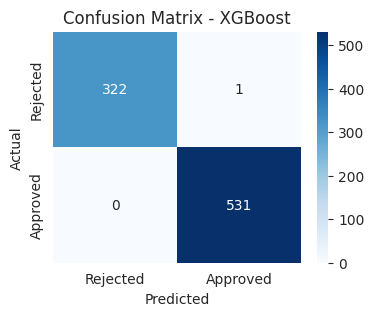

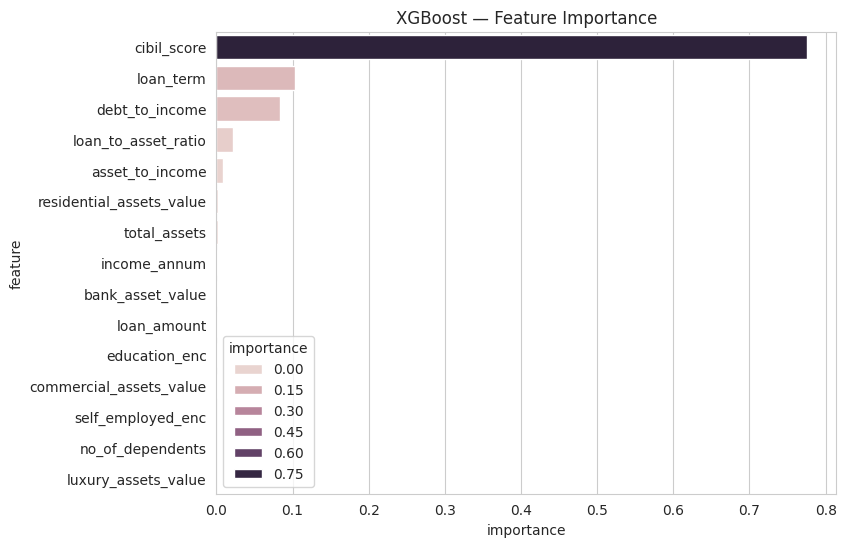

In [86]:
# 4. XGBoost
xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    random_state=42, eval_metric="logloss"
)
xgb.fit(X_train, y_train)
evaluate_model("XGBoost", xgb, X_test, y_test)

xgb_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="importance", y="feature", data=xgb_importance, hue='importance')
plt.title("XGBoost — Feature Importance")
plt.show()


## Step 10 — Summary of Findings & Recommendations




### 📌 Report

**Key drivers of `loan_status`:**
1. `cibil_score`
2. `debt_to_income` / `loan_amount`
3. `total_assets` / `loan_to_asset_ratio`

---

### Assumptions Made in This Analysis
1. `cibil_score` follows the standard 300–900 Indian credit score range.
2. All monetary columns (`income_annum`, `loan_amount`, asset values) are in the same currency/unit.
3. `loan_status` is a clean binary outcome (Approved/Rejected) with no partial/pending states.
4. Each row represents an independent applicant — no relationship or duplication across rows.
5. Self-reported asset values are assumed accurate (no external verification).
6. Missing values, if present, are assumed missing-at-random unless a pattern was found in Step 1.
7. No temporal dimension exists — `loan_id` order does not imply chronology, so trend-over-time analysis isn't possible.
8. The dataset is assumed representative of the broader applicant population (not biased toward one lender's unusually strict/lenient policy).

---

### Recommendations


**Business-side insight (what raises an applicant's actual approval odds):**
- Improving `cibil_score` is typically the single biggest lever — target score bands identified in Step 5.
- Lowering `debt_to_income` ratio (borrowing less relative to income, or demonstrating higher income).
- Increasing `total_assets` relative to the loan amount reduces perceived risk.
